# HMM and AR(1) models, exploration and simulation

## **Part 1** Simulating and plotting data

Simulation code provided by Gudmund (advisor)

In [30]:
import numpy as np

np.random.seed(1)

T = 500

# AR(1) parameters
rho = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])

# transition matrix
P = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])

states = np.zeros(T, dtype=int)
y = np.zeros(T)

# initial values
states[0] = np.random.choice([0,1])
y[0] = np.random.normal()

for t in range(1, T):

    # simulate next state
    states[t] = np.random.choice([0,1], p=P[states[t-1]])

    # simulate observation
    s = states[t]
    y[t] = rho[s]*y[t-1] + np.random.normal(scale=sigma[s])

### Plotting the simulated AR(1) series

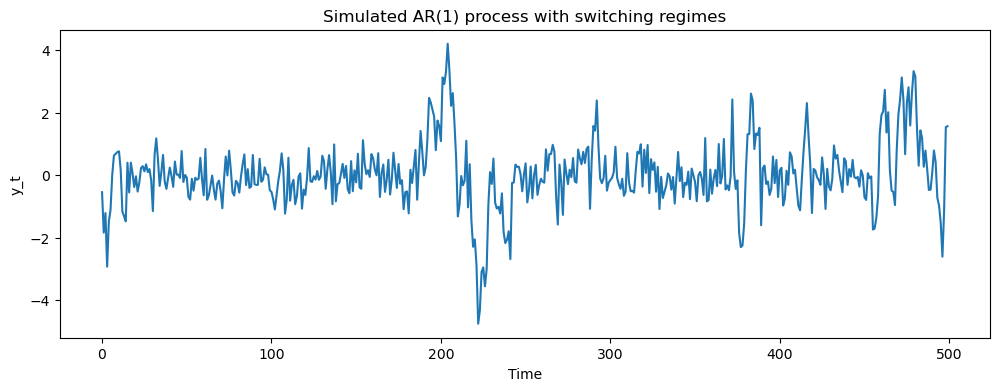

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Simulated AR(1) process with switching regimes")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.show()

### Plotting the hidden states

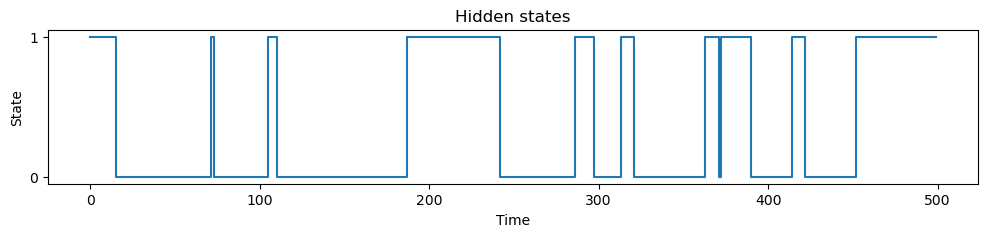

In [32]:
plt.figure(figsize=(12,2))
plt.step(range(T), states, where="post")
plt.title("Hidden states")
plt.xlabel("Time")
plt.ylabel("State")
plt.yticks([0,1])
plt.show()

### Combined plot

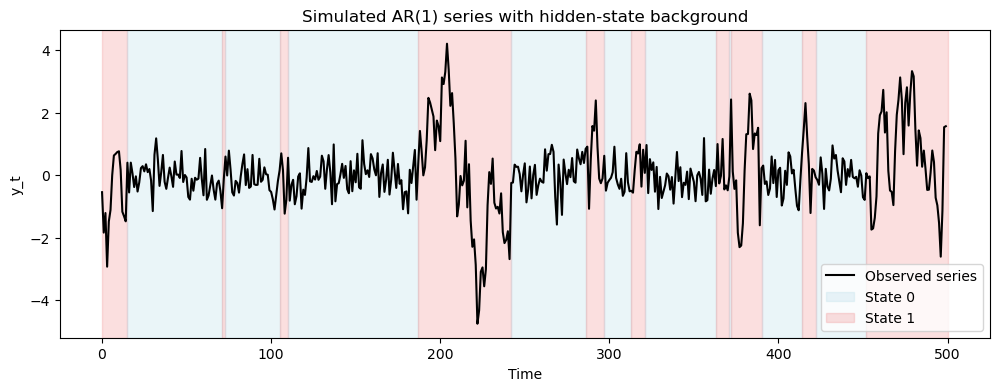

In [33]:
import matplotlib.patches as mpatches

state_colors = {
    0: "lightblue",
    1: "lightcoral"
}

plt.figure(figsize=(12, 4))
plt.plot(y, color="black", linewidth=1.5, label="Observed series")

start = 0
current_state = states[0]

for t in range(1, T):
    if states[t] != current_state:
        plt.axvspan(start, t, color=state_colors[current_state], alpha=0.25)
        start = t
        current_state = states[t]

plt.axvspan(start, T, color=state_colors[current_state], alpha=0.25)

legend_patches = [
    mpatches.Patch(color=state_colors[0], alpha=0.25, label="State 0"),
    mpatches.Patch(color=state_colors[1], alpha=0.25, label="State 1")
]

plt.legend(handles=[plt.Line2D([0], [0], color="black", label="Observed series")] + legend_patches)
plt.title("Simulated AR(1) series with hidden-state background")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.show()

### Simulation of a Regime-Switching AR(1) Process, summary

The code simulates a time series generated by an **AR(1) process whose parameters depend on an unobserved (hidden) state**. The hidden state evolves according to a **two-state Markov chain**.

First, two sets of AR(1) parameters are defined. Each state has its own autoregressive coefficient \( $\rho$ \) and innovation standard deviation \( $\sigma$ \). A **transition matrix** specifies the probability of switching between the two states at each time step.

The simulation proceeds recursively for \(T = 500\) observations. At each time step:

1. The next hidden state is drawn using the transition probabilities of the Markov chain.
2. Conditional on the current state, the observation is generated from the corresponding AR(1) model:
$$
y_t = \rho_s y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma_s^2)
$$

This produces two sequences:
- `states`: the simulated hidden regimes
- `y`: the observed time series

After running the simulation, the resulting AR(1) series is plotted. The background of the plot is shaded according to the hidden state, making it possible to visually identify the periods in which the process is governed by each regime.

## **Part 2** Estimate parameters using MLE and forward algorithm

### Imports

In [34]:
import pandas as pd
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from methods.hmm_ar1 import (
    simulate_rs_ar1,
    transform_params,
    obs_density,
    forward_algorithm,
    neg_loglik,
    fit_model,
    filtered_probs
)

### Simulate data with known parameters

In [35]:
T = 1000
seed = 1
# AR(1) parameters
beta = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])

# transition matrix
P = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])



y, states = simulate_rs_ar1(T=T, beta=beta, sigma=sigma, P=P, seed=seed)

print("")

### Estimate parameters

In [36]:
# Initial guess:
# [b1, b2, eta1, eta2, a1, a2]
theta0 = np.array([
    0.0,
    0.5,
    -0.5,
    0.0,
    2.0,
    2.0])

# Estimate model:
result, params_hat = fit_model(y, theta0)

# Print optimization info:
print("Converged:", result.success)

# Compare estimates with true parameters:
true_params = {
    "beta1": beta[0],
    "beta2": beta[1],
    "sigma1": sigma[0],
    "sigma2": sigma[1],
    "p11": P[0, 0],
    "p22": P[1, 1],
    "p12": P[0, 1],
    "p21": P[1, 0]
}

comparison = pd.DataFrame({
    "true": true_params,
    "estimated": params_hat
})

print("\nComparison table:")
print(comparison)


Converged: True

Comparison table:
        true  estimated
beta1   0.20   0.085118
beta2   0.80   0.842283
sigma1  0.50   0.504831
sigma2  1.00   0.956153
p11     0.95   0.977505
p22     0.95   0.969372
p12     0.05   0.022495
p21     0.05   0.030628


Comparing the true and simulated states, last 500 observations

In [37]:
n_plot = 500
idx = slice(-n_plot, None)
y_plot = y[idx]
states_plot = states[idx]
alpha_hat, _, _ = forward_algorithm(
    y=y,
    beta1=params_hat["beta1"],
    beta2=params_hat["beta2"],
    sigma1=params_hat["sigma1"],
    sigma2=params_hat["sigma2"],
    p11=params_hat["p11"],
    p22=params_hat["p22"]
)
probs_hat = filtered_probs(alpha_hat)
probs_plot = probs_hat[idx]

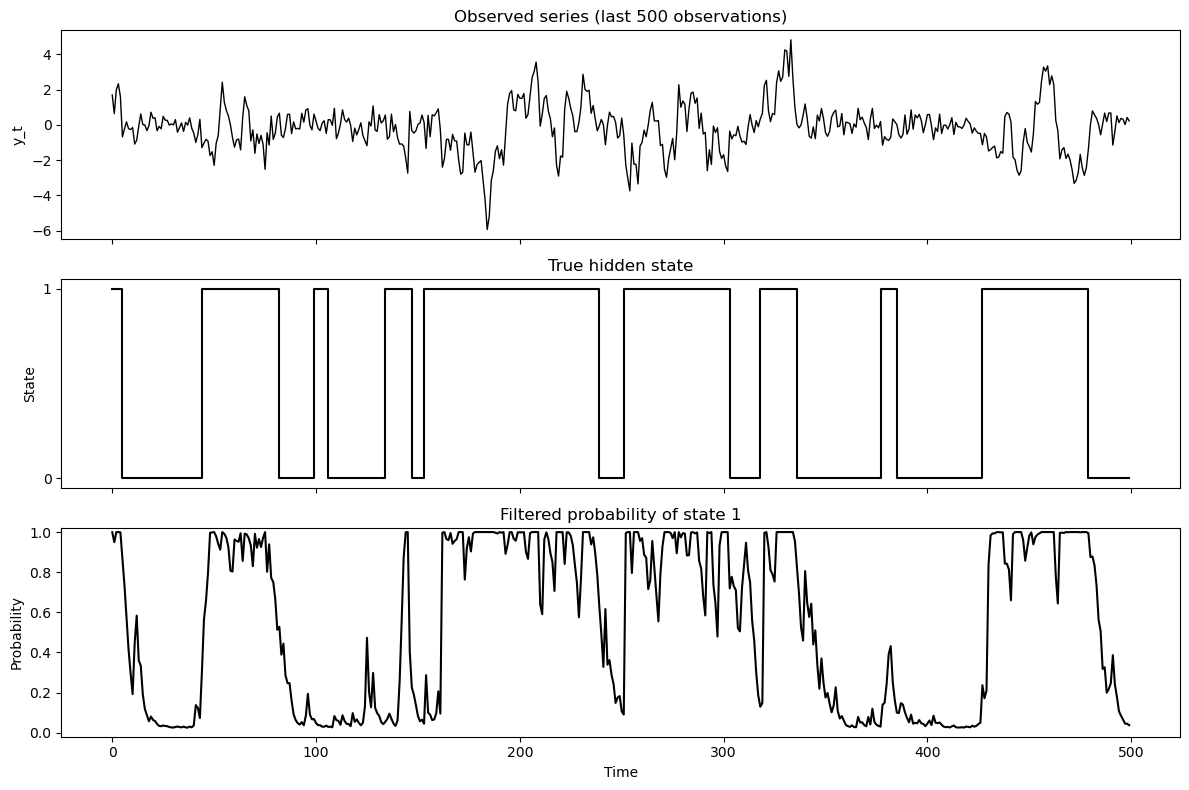

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Observed series
axes[0].plot(y_plot, color="black", linewidth=1)
axes[0].set_title("Observed series (last 500 observations)")
axes[0].set_ylabel("y_t")

# True hidden state
axes[1].step(range(n_plot), states_plot, where="post", color="black")
axes[1].set_title("True hidden state")
axes[1].set_ylabel("State")
axes[1].set_yticks([0, 1])

# Filtered probability
axes[2].plot(probs_plot[:, 1], color="black", linewidth=1.5)
axes[2].set_title("Filtered probability of state 1")
axes[2].set_ylabel("Probability")
axes[2].set_xlabel("Time")
axes[2].set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()

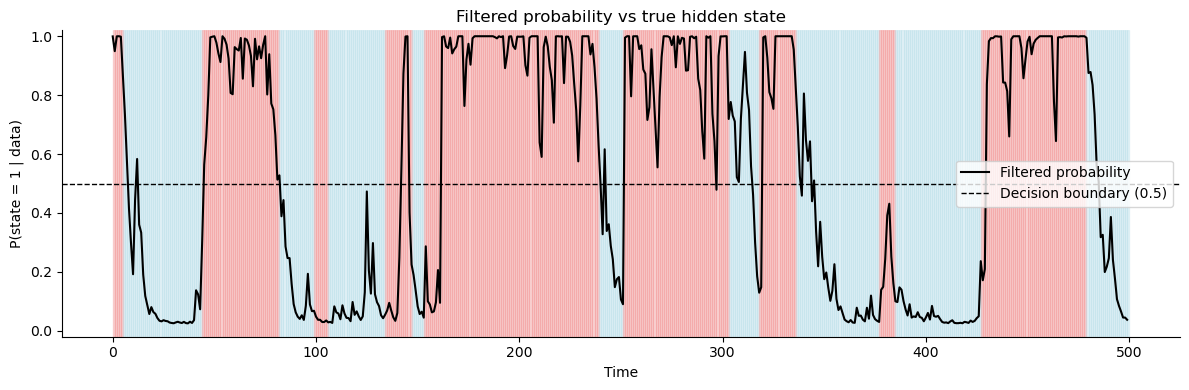

In [39]:
fig, ax = plt.subplots(figsize=(12,4))

# Background shading for true states
for t in range(n_plot):
    if states_plot[t] == 1:
        ax.axvspan(t, t+1, color="lightcoral", alpha=0.3)
    else:
        ax.axvspan(t, t+1, color="lightblue", alpha=0.3)

# Filtered probability
ax.plot(probs_plot[:,1], color="black", linewidth=1.5, label="Filtered probability")

# Decision boundary
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="Decision boundary (0.5)")

ax.set_ylabel("P(state = 1 | data)")
ax.set_xlabel("Time")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Filtered probability vs true hidden state")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

plt.tight_layout()
plt.show()

Now, using the 0.5 decision boundary:

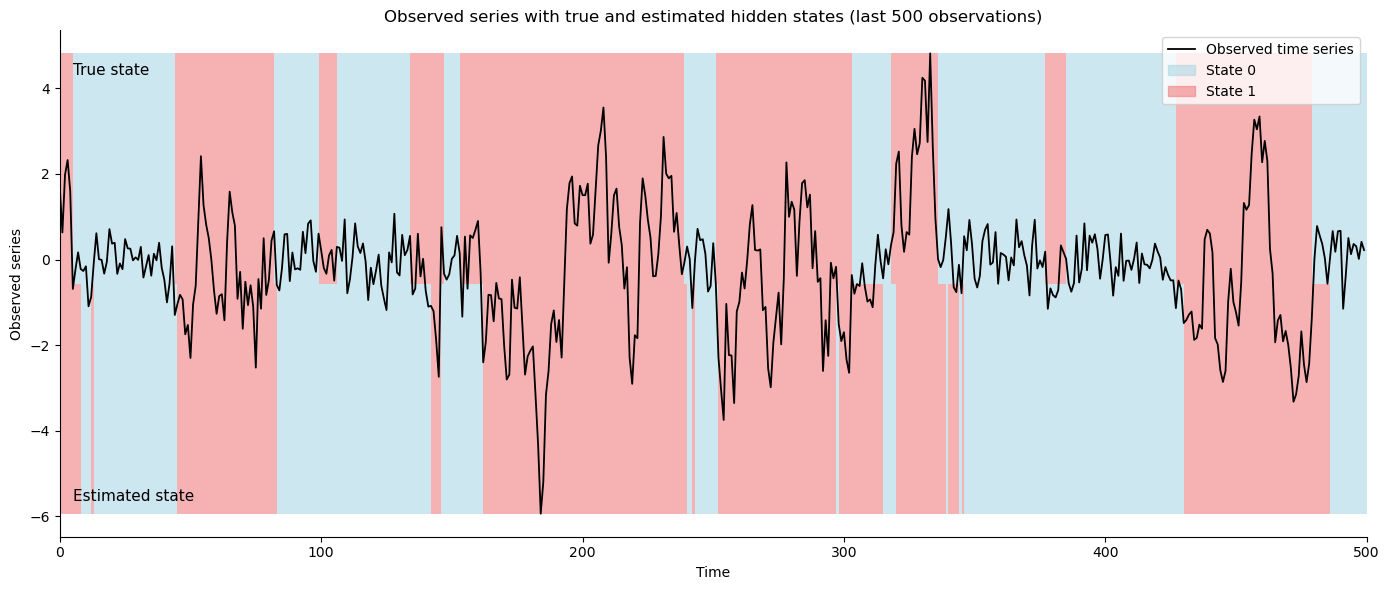

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Last 500 observations
n_plot = 500
idx = slice(-n_plot, None)

y_plot = y[idx]
states_true = states[idx]
probs_plot = probs_hat[idx]

# Hard classification using decision boundary
states_est = (probs_plot[:, 1] > 0.5).astype(int)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot observed time series
ax.plot(y_plot, color="black", linewidth=1.3, label="Observed time series", zorder=3)

# Determine vertical limits
ymin, ymax = y_plot.min(), y_plot.max()
y_mid = 0.5 * (ymin + ymax)

# Shade TRUE states (top half)
for t in range(n_plot):
    color_true = "lightcoral" if states_true[t] == 1 else "lightblue"
    ax.fill_between([t, t+1], y_mid, ymax, color=color_true, alpha=0.6, linewidth=0)

# Shade ESTIMATED states (bottom half)
for t in range(n_plot):
    color_est = "lightcoral" if states_est[t] == 1 else "lightblue"
    ax.fill_between([t, t+1], ymin, y_mid, color=color_est, alpha=0.6, linewidth=0)

# Labels
ax.text(5, ymax - 0.02*(ymax-ymin), "True state", fontsize=11, va="top")
ax.text(5, ymin + 0.02*(ymax-ymin), "Estimated state", fontsize=11, va="bottom")

# Formatting
ax.set_xlim(0, n_plot)
ax.set_xlabel("Time")
ax.set_ylabel("Observed series")
ax.set_title("Observed series with true and estimated hidden states (last 500 observations)")

# Legend
line_handle = plt.Line2D([0], [0], color="black", linewidth=1.3, label="Observed time series")
state0_patch = mpatches.Patch(color="lightblue", alpha=0.6, label="State 0")
state1_patch = mpatches.Patch(color="lightcoral", alpha=0.6, label="State 1")

ax.legend(handles=[line_handle, state0_patch, state1_patch], loc="upper right")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Misclassification plot

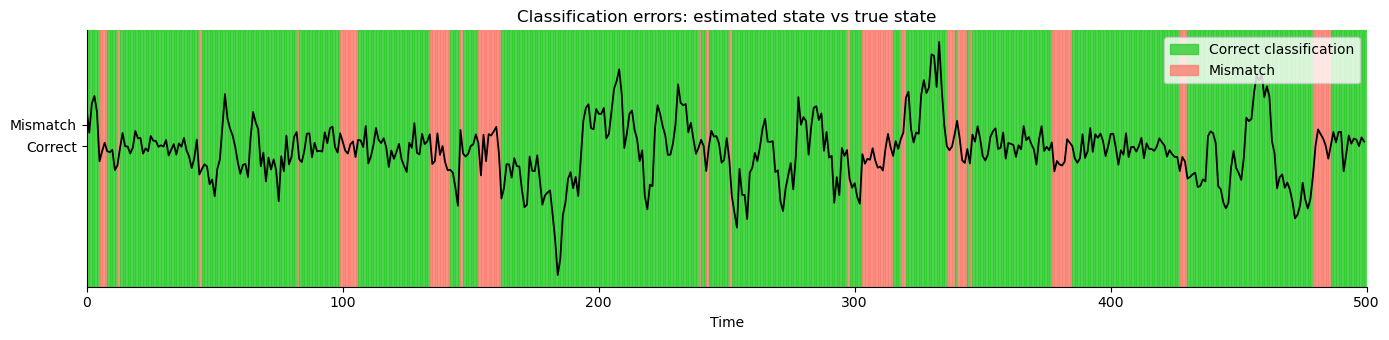

In [46]:
# Indicator for classification error
state_mismatch = (states_true != states_est).astype(int)

fig, ax = plt.subplots(figsize=(14, 3.5))

# Background shading: mismatch vs correct classification
for t in range(n_plot):
    color = "salmon" if state_mismatch[t] == 1 else "limegreen"
    ax.axvspan(t, t + 1, color=color, alpha=0.8)

# Plot observed time series
ax.plot(y_plot, color="black", linewidth=1.3, label="Observed time series", zorder=3)

ax.set_xlim(0, n_plot)
# ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Correct", "Mismatch"])
ax.set_xlabel("Time")
ax.set_title("Classification errors: estimated state vs true state")

# Legend
correct_patch = mpatches.Patch(color="limegreen", alpha=0.8, label="Correct classification")
mismatch_patch = mpatches.Patch(color="salmon", alpha=0.8, label="Mismatch")

ax.legend(handles=[correct_patch, mismatch_patch], loc="upper right")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()